In [1]:
%matplotlib inline
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({'mathtext.default':  'regular' })
FontSize=13
import pandas as pd
import calendar

In [2]:
def norm(data):
    min_val = min(data)
    max_val = max(data)
    normalized = [(x - min_val) / (max_val - min_val) for x in data]
    return normalized


In [3]:

with open("../EWF/marconi.txt", "r") as file:
    marconi_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/marconi.txt", "r") as file:
    marconi_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/fugaku.txt", "r") as file:
    fugaku_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/fugaku.txt", "r") as file:
    fugaku_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/polaris.txt", "r") as file:
    polaris_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/polaris.txt", "r") as file:
    polaris_wue= [float(line.strip()) for line in file if line.strip()]

with open("../EWF/frontier.txt", "r") as file:
    frontier_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/frontier.txt", "r") as file:
    frontier_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../CI/marconi.txt", "r") as file:
    ci_marconi= [float(line.strip()) for line in file if line.strip()]
with open("../CI/fugaku.txt", "r") as file:
    ci_fugaku= [float(line.strip()) for line in file if line.strip()]
with open("../CI/polaris.txt", "r") as file:
    ci_polaris= [float(line.strip()) for line in file if line.strip()]
with open("../CI/frontier.txt", "r") as file:
    ci_frontier= [float(line.strip()) for line in file if line.strip()]

In [4]:


wi_marconi  =[]
wi_fugaku  =[]
wi_polaris  =[]
wi_frontier  =[]
wsi_direct = [0.29, 0.36, 0.4237, 0.2716]
wsi_indirect = [0.29, 0.36, 0.39303875326672477, 0.2801834775358028]

offsite_marconi = []
offsite_fugaku = []
offsite_polaris = []
offsite_frontier = []

onsite_marconi = []
onsite_fugaku = []
onsite_polaris = []
onsite_frontier = []
for i in range(0,len(marconi_ewf)):
    wi_marconi.append(1.25*marconi_ewf[i]*(wsi_indirect[0]) + marconi_wue[i]*(wsi_direct[0]))
    wi_fugaku.append(1.4*fugaku_ewf[i]*(wsi_indirect[1]) + fugaku_wue[i]*(wsi_direct[1]))
    wi_polaris.append(1.65*polaris_ewf[i]*(wsi_indirect[2]) + polaris_wue[i]*(wsi_direct[2]))
    wi_frontier.append(1.05*frontier_ewf[i]*(wsi_indirect[3]) + frontier_wue[i]*(wsi_direct[3]))
    
    
    offsite_marconi.append(1.25*marconi_ewf[i]*(wsi_indirect[0]))
    offsite_fugaku.append(1.4*fugaku_ewf[i]*(wsi_indirect[1]))
    offsite_polaris.append(1.65*polaris_ewf[i]*(wsi_indirect[2]))
    offsite_frontier.append(1.05*frontier_ewf[i]*(wsi_indirect[3]))
    
    onsite_marconi.append(marconi_wue[i]*(wsi_direct[0]))
    onsite_fugaku.append(fugaku_wue[i]*(wsi_direct[1]))
    onsite_polaris.append(polaris_wue[i]*(wsi_direct[2]))
    onsite_frontier.append(frontier_wue[i]*(wsi_direct[3]))

days_in_month = [31,28,31,30,31,30,31,31,30,31,30,31]
hours_in_month = [d * 24 for d in days_in_month]

month_labels = []
for i, h in enumerate(hours_in_month):
    month_labels += [i+1] * h
month_labels = np.array(month_labels)

df = pd.DataFrame({
    'month': month_labels,
    'Marconi': wi_marconi,
    'Fugaku': wi_fugaku,
    'Polaris': wi_polaris,
    'Frontier': wi_frontier
})

df2 = pd.DataFrame({
    'month': month_labels,
    'Marconi': ci_marconi,
    'Fugaku': ci_fugaku,
    'Polaris': ci_polaris,
    'Frontier': ci_frontier
})
df3 = pd.DataFrame({
    'month': month_labels,
    'Marconi': offsite_marconi,
    'Fugaku': offsite_fugaku,
    'Polaris': offsite_polaris,
    'Frontier': offsite_frontier
})

df4 = pd.DataFrame({
    'month': month_labels,
    'Marconi': onsite_marconi,
    'Fugaku': onsite_fugaku,
    'Polaris': onsite_polaris,
    'Frontier': onsite_frontier
})

monthly_avg = df.groupby('month').mean()
marconi_monthly = monthly_avg['Marconi'].tolist()
fugaku_monthly = monthly_avg['Fugaku'].tolist()
polaris_monthly = monthly_avg['Polaris'].tolist()
frontier_monthly = monthly_avg['Frontier'].tolist()    


ci_monthly_avg = df2.groupby('month').mean()
ci_marconi_monthly = ci_monthly_avg['Marconi'].tolist()
ci_fugaku_monthly = ci_monthly_avg['Fugaku'].tolist()
ci_polaris_monthly = ci_monthly_avg['Polaris'].tolist()
ci_frontier_monthly = ci_monthly_avg['Frontier'].tolist()

offsite_avg = df3.groupby('month').mean()
offsite_marconi_monthly = offsite_avg['Marconi'].tolist()
offsite_fugaku_monthly = offsite_avg['Fugaku'].tolist()
offsite_polaris_monthly = offsite_avg['Polaris'].tolist()
offsite_frontier_monthly = offsite_avg['Frontier'].tolist()

onsite_avg = df4.groupby('month').mean()
onsite_marconi_monthly = onsite_avg['Marconi'].tolist()
onsite_fugaku_monthly = onsite_avg['Fugaku'].tolist()
onsite_polaris_monthly = onsite_avg['Polaris'].tolist()
onsite_frontier_monthly = onsite_avg['Frontier'].tolist()


ci_marconi_norm = norm(ci_marconi_monthly)
ci_fugaku_norm = norm(ci_fugaku_monthly)
ci_polaris_norm = norm(ci_polaris_monthly)
ci_frontier_norm = norm(ci_frontier_monthly)
wi_marconi_norm = norm(marconi_monthly)
wi_fugaku_norm = norm(fugaku_monthly)
wi_polaris_norm = norm(polaris_monthly)
wi_frontier_norm = norm(frontier_monthly)

offsite_marconi_norm = norm(offsite_marconi_monthly)
offsite_fugaku_norm = norm(offsite_fugaku_monthly)
offsite_polaris_norm = norm(offsite_polaris_monthly)
offsite_frontier_norm = norm(offsite_frontier_monthly)

onsite_marconi_norm = norm(onsite_marconi_monthly)
onsite_fugaku_norm = norm(onsite_fugaku_monthly)
onsite_polaris_norm = norm(onsite_polaris_monthly)
onsite_frontier_norm = norm(onsite_frontier_monthly)

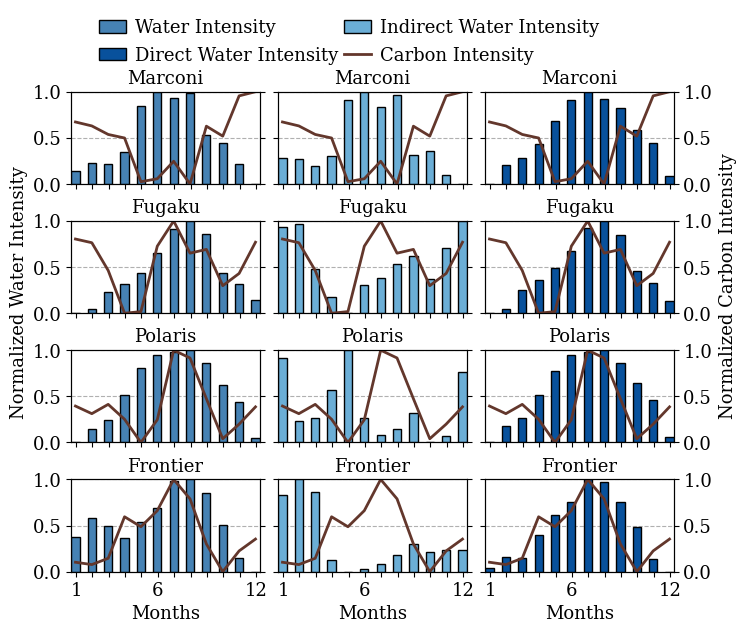

In [5]:
fig, axs = plt.subplots(nrows=4, ncols=3, gridspec_kw={'hspace': 0.4, 'wspace': 0.1, 'bottom': 0.2, 
                    'top': 0.8, 'right':0.995, 'left':0.17}, figsize=(7.3,8),sharex=True,sharey=True)
barWidth = 0.5
r1 = np.arange(12)
wi = [wi_marconi_norm, wi_fugaku_norm, wi_polaris_norm, wi_frontier_norm]  
ci = [ci_marconi_norm, ci_fugaku_norm, ci_polaris_norm, ci_frontier_norm]
offsite_wi = [offsite_marconi_norm, offsite_fugaku_norm, offsite_polaris_norm, offsite_frontier_norm]
onsite_wi = [onsite_marconi_norm, onsite_fugaku_norm, onsite_polaris_norm, onsite_frontier_norm]
ax2s = []
ax3s = []
ax4s = []
titles = ['Marconi', 'Fugaku', 'Polaris', 'Frontier']
for i in range(4):
    axs[i][0].bar(r1,wi[i], width = barWidth, color = '#4682B4', edgecolor = 'black',capsize=FontSize, label='Water Intensity',zorder=3)
    axs[i][0].set_ylim(0, 1)
    axs[i][1].set_ylim(0, 1)
    axs[i][2].set_ylim(0, 1)
    axs[i][0].grid(axis='y', linestyle='--')
    axs[i][0].set_title(titles[i], fontsize=FontSize)
    axs[i][1].set_title(titles[i], fontsize=FontSize)
    axs[i][2].set_title(titles[i], fontsize=FontSize)
    axs[i][1].grid(axis='y', linestyle='--')
    axs[i][2].grid(axis='y', linestyle='--')
    axs[i][0].tick_params(axis='both', which='major', labelsize=FontSize)
    axs[i][1].tick_params(axis='both', which='major', labelsize=FontSize)
    axs[i][2].tick_params(axis='both', which='major', labelsize=FontSize)
    axs[i][0].set_xticks([k+0.035 for k in range(12)],labels=calendar.month_abbr[1:], rotation=0)
    axs[i][0].set_xlim(-0.25, 11.25)
    axs[i][1].bar(r1,offsite_wi[i], width = barWidth, color = '#6baed6', edgecolor = 'black',capsize=FontSize, label='Indirect Water Intensity',zorder=3)
    axs[i][2].bar(r1,onsite_wi[i], width = barWidth, color ='#08519c', edgecolor = 'black',capsize=FontSize, label='Direct Water Intensity',zorder=3)
    ax2s.append(axs[i][0].twinx())
    ax3s.append(axs[i][1].twinx())
    ax4s.append(axs[i][2].twinx())
axs[0][0].legend(loc=(0.1,1.5), fontsize=FontSize, frameon=False, ncol=4 ,handlelength=1.5, handletextpad=0.5, borderpad=0.5)
axs[3][0].set_xlabel('Months', fontsize=FontSize)
axs[3][1].set_xlabel('Months', fontsize=FontSize)
axs[3][2].set_xlabel('Months', fontsize=FontSize)
for i in range(4):
    ax2s[i].plot([i for i in range(12)],ci[i], color = "#63372C",label = "Carbon Intensity", linewidth = 2, linestyle='-', zorder=2)
    ax2s[i].set_ylim(0, 1)
    ax3s[i].set_ylim(0, 1)
    ax2s[i].set_xticklabels([])
    ax2s[i].set_yticklabels([])
    ax3s[i].set_yticklabels([])
    ax3s[i].plot([i for i in range(12)],ci[i], color = "#63372C",  label = "Carbon Intensity", linewidth = 2, linestyle='-', zorder=2)
    ax3s[i].tick_params(axis='both', which='major', labelsize=FontSize)
    ax4s[i].plot([i for i in range(12)],ci[i], color = "#63372C",label = "Direct Water Intensity", linewidth = 2, linestyle='-', zorder=2)
    ax4s[i].set_ylim(0, 1)
    ax4s[i].tick_params(axis='both', which='major', labelsize=FontSize)
ax2s[0].legend(loc=(1.4,1.2), fontsize=FontSize, frameon=False, ncol=4 ,handlelength=1.5, handletextpad=0.5, borderpad=0.5)
axs[0][1].legend(loc=(0.3,1.5), fontsize=FontSize, frameon=False, ncol=4 ,handlelength=1.5, handletextpad=0.5, borderpad=0.5)
axs[0][2].legend(loc=(-2.1,1.2), fontsize=FontSize, frameon=False, ncol=4 ,handlelength=1.5, handletextpad=0.5, borderpad=0.5)
axs[0][0].text(-4, -2.5, 'Normalized Water Intensity', fontsize=FontSize, rotation=90)
ax3s[0].text(26.7, -2.5, 'Normalized Carbon Intensity', fontsize=FontSize, rotation=90)

month_labels = ["1", "", "", "", "", "6", 
                "", "", "", "", "", "12"]

axs[3][0].set_xticklabels(month_labels, fontsize=FontSize)
axs[3][1].set_xticklabels(month_labels, fontsize=FontSize)
plt.savefig('../figures/figure12.pdf', bbox_inches='tight')
